# 03 · V-map per-spot relative volume + soft beam attribution

The V-map machinery turns measured spot intensities into a per-voxel
**relative scattering volume** map, jointly with per-ring scale factors
`K`, optional absorption `mu`, and a refinable beam profile. It is driven
by two flag groups:

- `--vmap-run` enables the `calc_radius_v` + `refine_vmap` stages.
- `--soft-attribution` swaps the indexer's hard voxel assignment for a
  continuous beam-weight profile (`gaussian` / `tophat` / `tophat-ramp`).

This notebook runs them on the synthetic **FF** case. Two things to
understand up front:

1. `calc_radius_v` computes the **per-spot relative volume**
   `V_rel = I_obs / I_theory(ring)` from the indexed spots and a crystal
   model — this *is* the raw V-map signal, and it runs on FF.
2. The **joint** `refine_vmap` step (and `--soft-attribution` in the
   indexer) operate over a **multi-scan voxel grid**, which is a PF
   concept: with a single FF beam position there is exactly one voxel and
   nothing to attribute across. So on FF, `refine_vmap` skips with a
   precise reason and the soft-attribution profile is a no-op in the FF
   indexer. We show the V-map signal that *does* exist on FF and explain
   the PF requirement.

> **Runtime** ~1–1.5 min on CPU.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import shutil
import subprocess
import sys
import tempfile
import time
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from midas_pipeline import __version__
print('midas-pipeline', __version__)

midas-pipeline 0.2.1


## 1. Synthetic dataset + a tiny Au crystal model

`calc_radius_v` needs a crystal structure to predict per-ring theoretical
intensities. We write a minimal Au CIF (FCC, a=4.08 Å) inline so the
notebook stays self-contained.

In [2]:
from midas_ff_pipeline.testing import generate_synthetic_dataset

MIDAS_HOME = Path(os.environ.get('MIDAS_HOME') or Path.home() / 'opt' / 'MIDAS')
PARAMS_TEMPLATE = MIDAS_HOME / 'FF_HEDM' / 'Example' / 'Parameters.txt'

WORK = Path(tempfile.mkdtemp(prefix='midas_pipeline_vmap_'))
AU_CIF = WORK / 'Au.cif'
AU_CIF.write_text("data_Au\n_cell_length_a 4.08\n_cell_length_b 4.08\n_cell_length_c 4.08\n_cell_angle_alpha 90.0\n_cell_angle_beta 90.0\n_cell_angle_gamma 90.0\n_symmetry_space_group_name_H-M 'F m -3 m'\n_symmetry_Int_Tables_number 225\nloop_\n_atom_site_label\n_atom_site_type_symbol\n_atom_site_fract_x\n_atom_site_fract_y\n_atom_site_fract_z\n_atom_site_occupancy\nAu1 Au 0.0 0.0 0.0 1.0\n")

zarr = generate_synthetic_dataset(
    out_dir=WORK / 'sim', params_template=PARAMS_TEMPLATE,
    n_grains=20, n_cpus=4,
)
print('cif  :', AU_CIF)
print('zarr :', zarr)

cif  : /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/midas_pipeline_vmap_7ytxk4mp/Au.cif
zarr : /private/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/midas_pipeline_vmap_7ytxk4mp/sim/midas_ff_pipeline_synth_det1.analysis.MIDAS.zip


## 2. Run with `--vmap-run` + `--soft-attribution`

We run the FF pipeline through indexing, then the V-map stages. The
soft-attribution flags are accepted and threaded through; on FF they
configure a beam profile the (single-voxel) FF indexer does not need to
apply, which is exactly the degeneracy this package makes explicit.

In [3]:
RESULT = WORK / 'run'
cmd = [
    sys.executable, '-m', 'midas_pipeline', 'run', '--scan-mode', 'ff',
    '--params', str(WORK / 'sim' / PARAMS_TEMPLATE.name),
    '--result', str(RESULT), '--zarr', str(zarr),
    '--n-cpus', '4', '--device', 'cpu', '--dtype', 'float64',
    '--indexer-backend', 'python',
    '--vmap-run',
    '--vmap-crystal-cif', str(WORK / 'Au.cif'),
    '--vmap-wavelength', '0.22291',
    '--vmap-emit-diagnostics', '1',
    '--soft-attribution', '--soft-profile', 'gaussian',
    '--skip', 'refinement', '--skip', 'process_grains', '--skip', 'consolidation',
]
t0 = time.time()
proc = subprocess.run(cmd, capture_output=True, text=True)
print(f'exit={proc.returncode} ({time.time() - t0:.1f}s)\n')
for line in proc.stderr.splitlines():
    if any(k in line.lower() for k in ('calc_radius_v', 'refine_vmap', 'soft', 'indexing(ff)')):
        print(' ', line.split('] ', 1)[-1])
assert proc.returncode == 0, proc.stderr[-2000:]

exit=0 (44.3s)

  midas_pipeline: indexing(FF): 93 / 109 seeds with non-zero data
  midas_pipeline: → calc_radius_v
  midas_pipeline: calc_radius_v: wrote 2136-spot Radius_V.csv (2136 valid V_rel) and 5-ring I_theory.csv in 0.10s
  midas_pipeline: ✓ calc_radius_v — 0.10s
  midas_pipeline: → refine_vmap
  midas_pipeline: refine_vmap: /private/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/midas_pipeline_vmap_7ytxk4mp/run/LayerNr_1/Output/voxel_grid.csv not present; the refine_vmap stage requires a (voxel_idx, x, y, z, grain_id) table. Skipping.
  midas_pipeline: stage 'refine_vmap' is a P1 stub — implementation lands in a later phase. Skipping in scan_mode=ff.
  midas_pipeline: ✓ refine_vmap — 0.00s


## 3. The V-map signal (`Radius_V.csv`)

`calc_radius_v` writes one row per indexed spot with its relative volume
`V_rel = I_obs / I_theory(ring)`. We load it and visualise the V-map two
ways:

- the distribution of per-spot `V_rel`, and
- `V_rel` laid out on the detector ring/eta map (the diagnostic image).

In [4]:
out = RESULT / 'LayerNr_1' / 'Output'
radius_v = out / 'Radius_V.csv'
theory = out / 'I_theory_per_ring.csv'
print('Radius_V.csv         ', radius_v.stat().st_size, 'bytes')
print('I_theory_per_ring.csv', theory.stat().st_size, 'bytes')

arr = np.loadtxt(radius_v, comments='#', skiprows=1)
# cols: spot_id scan_nr ring_number ring_idx intensity V_rel omega_deg eta_deg
ring_number = arr[:, 2].astype(int)
intensity   = arr[:, 4]
v_rel       = arr[:, 5]
eta_deg     = arr[:, 7]
print(f'{arr.shape[0]} spots; V_rel in [{v_rel.min():.3g}, {v_rel.max():.3g}], '
      f'median {np.median(v_rel):.3g}')

Radius_V.csv          124546 bytes
I_theory_per_ring.csv 157 bytes
2136 spots; V_rel in [2.78e-07, 0.000856], median 0.000248


In [5]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))

ax0.hist(v_rel[v_rel > 0], bins=40, color='steelblue', edgecolor='k', lw=0.3)
ax0.set_xlabel('per-spot relative volume V_rel = I_obs / I_theory(ring)')
ax0.set_ylabel('spot count')
ax0.set_title('V-map signal distribution')

sc = ax1.scatter(eta_deg, ring_number, c=v_rel, s=14, cmap='viridis',
                 norm=matplotlib.colors.LogNorm(vmin=max(v_rel[v_rel > 0].min(), 1e-3),
                                                 vmax=v_rel.max()))
ax1.set_xlabel('eta (deg)')
ax1.set_ylabel('ring number')
ax1.set_title('V_rel on the ring / eta map')
fig.colorbar(sc, ax=ax1, label='V_rel')
fig.tight_layout()

diag_png = WORK / 'v_map_diagnostic.png'
fig.savefig(diag_png, dpi=110)
plt.close(fig)
print('wrote V-map diagnostic image ->', diag_png)

wrote V-map diagnostic image -> /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/midas_pipeline_vmap_7ytxk4mp/v_map_diagnostic.png


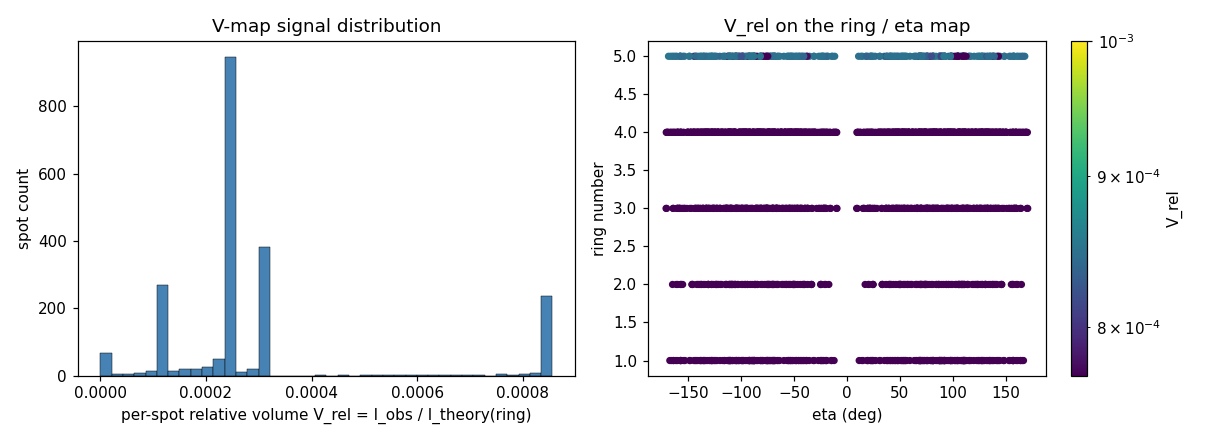

In [6]:
from IPython.display import Image, display
display(Image(filename=str(WORK / 'v_map_diagnostic.png')))

## 4. Why the joint refinement / soft attribution need PF

The log above shows `refine_vmap` skipping with:

> *`voxel_grid.csv` not present; the refine_vmap stage requires a
> (voxel_idx, x, y, z, grain_id) table.*

That is the correct, designed behaviour — **not** a failure. The *joint*
V-map refinement (`refine_vmap_joint`) optimises one `V` value per
**voxel**, and `--soft-attribution` distributes each spot's contribution
across voxels under a beam profile. Both require a **multi-scan voxel
grid**, which only exists in PF mode (`--scan-mode pf`, `n_scans ≥ 2`).
In FF there is a single beam position — one voxel — so there is nothing
to attribute across and no voxel grid to refine. This is precisely the
"FF is the single-scan degeneracy of PF" thesis: the per-spot V-map
signal (section 3) is the FF-observable part; the spatial V-map is what
the extra scan positions in PF unlock.

A full PF demonstration additionally needs a multi-scan synthetic
generator; `midas_ff_pipeline.testing` ships only single-scan FF
generators today, so the spatially-resolved V-map / soft-attribution
demo is left for when a PF synthetic generator lands.

In [7]:
shutil.rmtree(WORK, ignore_errors=True)
print('cleaned', WORK)

cleaned /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/midas_pipeline_vmap_7ytxk4mp
